# Identifying Districts for Aadhaar Biometric Update Awareness Camps

### UIDAI Data Hackathon 2026

**Objective:**  
To identify districts with low preparedness for mandatory Aadhaar biometric updates
(at age 15) and recommend targeted awareness camps using UIDAI-provided datasets.

**Datasets Used:**  
- Aadhaar Biometric Update Dataset (Primary)  
- Aadhaar Demographic Update Dataset (Supporting)

**Level of Analysis:** District-level, Pan-India

## 1. Problem Statement and Approach

Under UIDAI guidelines, biometric updates are mandatory for Aadhaar holders upon
reaching the age of 15. However, uneven biometric update activity across districts
suggests gaps in awareness, accessibility, or service outreach.

This project aims to:
- Quantify district-level preparedness for biometric updates among adolescents
- Identify districts with consistently low preparedness
- Recommend targeted awareness and biometric update camps as a policy intervention

The analysis adopts a data-driven, explainable approach using age-wise Aadhaar
update transaction data provided by UIDAI.

## 2. Datasets Used

### Aadhaar Biometric Update Dataset (Primary)
This dataset contains district-level counts of biometric update transactions
segregated by age groups.

**Key columns used:**
- State Name
- District Name
- Biometric updates for ages 5–17
- Biometric updates for ages 17 and above

### Aadhaar Demographic Update Dataset (Supporting)
This dataset captures demographic update transactions and is used to assess
overall service engagement patterns among adolescents.

**Important Note:**  
All values represent *transaction counts*, not population counts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bio = pd.read_csv("c:\\Users\\Sudeep\\Downloads\\api_data_aadhar_biometric\\api_data_aadhar_biometric_0_500000.csv")
demo = pd.read_csv("c:\\Users\\Sudeep\\Downloads\\api_data_aadhar_demographic_0_500000.csv")

## 3. Data Cleaning and Preprocessing

The datasets were cleaned to:
- Remove missing or invalid records
- Retain only relevant age-wise columns
- Aggregate transaction counts at the district level
- Remove districts with extremely low activity to avoid noise


In [3]:
# Cleaning the Biometric Dataset
bio_cols = [
    "state",
    "district",
    "bio_age_5_17",
    "bio_age_17_"
]

bio = bio[bio_cols].dropna()

bio = bio[
    (bio["bio_age_5_17"] >= 0) &
    (bio["bio_age_17_"] >= 0)
]

In [4]:
# Cleaning the Demographic Dataset
demo_cols = [
    "state",
    "district",
    "demo_age_5_17",
    "demo_age_17_"
]

demo = demo[demo_cols].dropna()

demo = demo[
    (demo["demo_age_5_17"] >= 0) &
    (demo["demo_age_17_"] >= 0)
]

In [5]:
# Biometric aggregation
bio_dist = (
    bio.groupby(["state", "district"], as_index=False)
       .sum()
)

bio_dist["bio_total"] = (
    bio_dist["bio_age_5_17"] + bio_dist["bio_age_17_"]
)

# Remove low-activity noise
bio_dist = bio_dist[bio_dist["bio_total"] > 50]

In [6]:
# Demographic aggregation
demo_dist = (
    demo.groupby(["state", "district"], as_index=False)
        .sum()
)

demo_dist["demo_total"] = (
    demo_dist["demo_age_5_17"] + demo_dist["demo_age_17_"]
)

demo_dist = demo_dist[demo_dist["demo_total"] > 50]

## 4. Methodology

A **Biometric Update Preparedness Score** was computed for each district as:

Preparedness Score =  
(Biometric updates for ages 5–17) ÷ (Total biometric updates)

This metric reflects the relative level of adolescent biometric update activity
within a district.

A **Demographic Engagement Score** was computed separately to assess general
service engagement patterns and validate whether low biometric preparedness
corresponds to broader awareness gaps.

In [7]:
# Biometric Preparedness Score
bio_dist["bio_preparedness_score"] = (
    bio_dist["bio_age_5_17"] / bio_dist["bio_total"]
)

bio_dist["bio_preparedness_percent"] = (
    bio_dist["bio_preparedness_score"] * 100
)

In [8]:
# Demographic Engagement Score
demo_dist["demo_engagement_score"] = (
    demo_dist["demo_age_5_17"] / demo_dist["demo_total"]
)

demo_dist["demo_engagement_percent"] = (
    demo_dist["demo_engagement_score"] * 100
)

In [9]:
# Combined data
combined = pd.merge(
    bio_dist,
    demo_dist,
    on=["state", "district"],
    how="inner"
)

## 5. Data Analysis and Visualisation

The following section presents key findings derived from the analysis,
supported by visualisations.

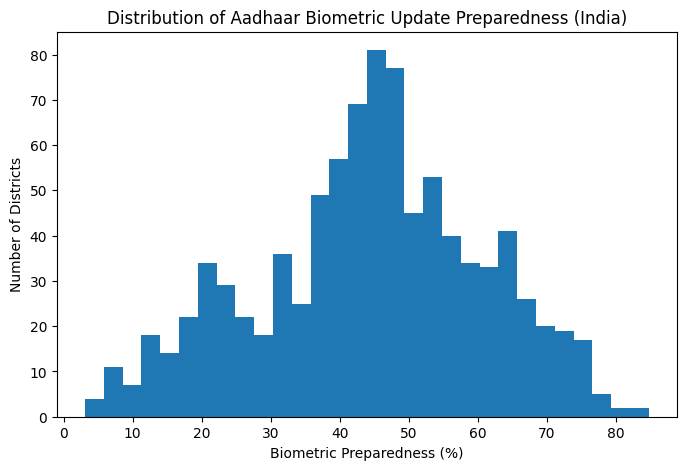

In [10]:
# Distribution of Biometric preparedness
plt.figure(figsize=(8,5))
plt.hist(combined["bio_preparedness_percent"], bins=30)
plt.xlabel("Biometric Preparedness (%)")
plt.ylabel("Number of Districts")
plt.title("Distribution of Aadhaar Biometric Update Preparedness (India)")
plt.show()

In [11]:
# Risk Classification
combined["risk_category"] = pd.qcut(
    combined["bio_preparedness_score"],
    q=[0, 0.1, 0.3, 1.0],
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

In [12]:
# Priority Districts
high_risk = (
    combined[combined["risk_category"] == "High Risk"]
    .sort_values("bio_preparedness_score")
)

high_risk[
    ["state", "district", "bio_preparedness_percent", "demo_engagement_percent"]
].head(10)

,state,district,bio_preparedness_percent,demo_engagement_percent
491,Maharashtra,Nandurbar *,3.095975,0.000000
636,Punjab,Nawanshahr,4.382470,1.230012
193,Delhi,North East,4.902752,3.637485
176,Chhattisgarh,Sarangarh-Bilaigarh,5.759162,8.082027
614,Pondicherry,Karaikal,6.006006,1.976285
190,Delhi,Najafgarh,6.015038,0.000000
203,Gujarat,Ahmadabad,6.662579,4.861504
499,Maharashtra,Raigarh(MH),6.666667,3.007519
168,Chhattisgarh,Manendragarh–Chirmiri–Bharatpur,7.086614,9.321267
27,Andhra Pradesh,Mahabub Nagar,7.313258,3.389831


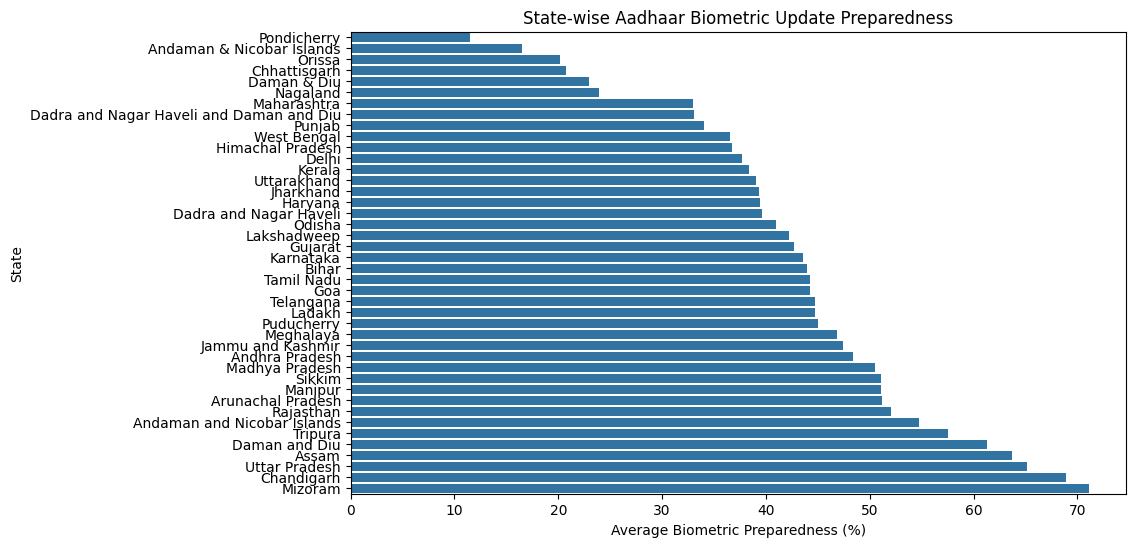

In [13]:
# State-wise Preparedness
state_avg = (
    combined.groupby("state", as_index=False)
            .agg({"bio_preparedness_percent": "mean"})
            .sort_values("bio_preparedness_percent")
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=state_avg,
    x="bio_preparedness_percent",
    y="state"
)
plt.xlabel("Average Biometric Preparedness (%)")
plt.ylabel("State")
plt.title("State-wise Aadhaar Biometric Update Preparedness")
plt.show()

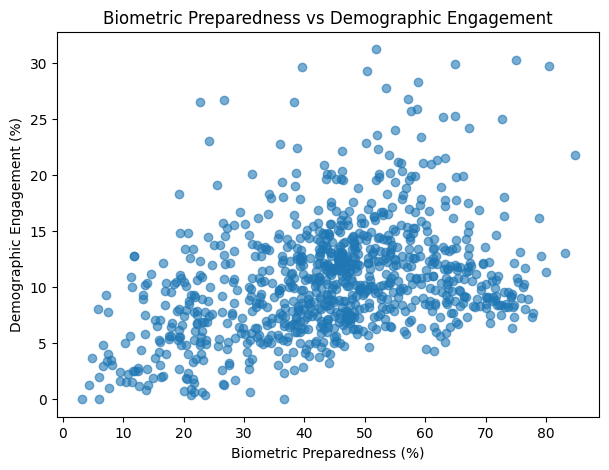

In [14]:
# Biometric VS Demographic Comparison
plt.figure(figsize=(7,5))
plt.scatter(
    combined["bio_preparedness_percent"],
    combined["demo_engagement_percent"],
    alpha=0.6
)
plt.xlabel("Biometric Preparedness (%)")
plt.ylabel("Demographic Engagement (%)")
plt.title("Biometric Preparedness vs Demographic Engagement")
plt.show()

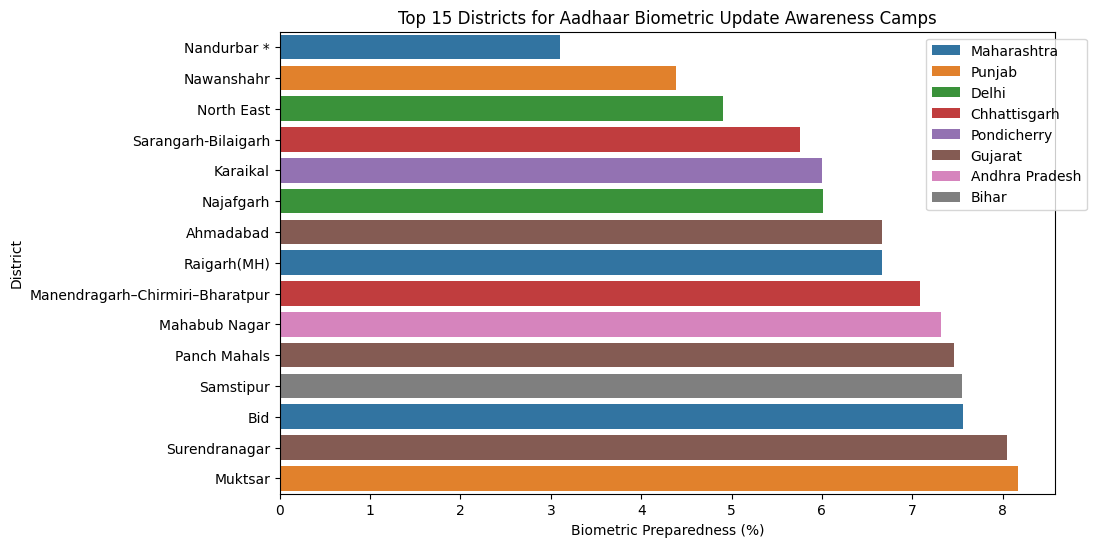

In [15]:
# Top 15 districts requiring Awareness Camp
top15 = high_risk.head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top15,
    x="bio_preparedness_percent",
    y="district",
    hue="state",
    dodge=False
)
plt.xlabel("Biometric Preparedness (%)")
plt.ylabel("District")
plt.title("Top 15 Districts for Aadhaar Biometric Update Awareness Camps")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [16]:
high_risk.to_csv(
    "high_risk_biometric_update_districts.csv",
    index=False
)

## 6. Policy Recommendations

Based on the findings, the following interventions are recommended:

- School-linked biometric update camps for adolescents
- Mobile Aadhaar enrolment units in high-risk districts
- Pre-age-15 awareness drives through schools and Anganwadis
- District-level monitoring of biometric update preparedness

These measures can improve compliance, reduce future authentication failures,
and enhance service delivery.

## 7. Conclusion

This study demonstrates how UIDAI’s existing datasets can be leveraged to
identify districts with low biometric update preparedness. By adopting a
targeted, data-driven awareness strategy, UIDAI can improve Aadhaar update
compliance while optimising outreach resources.